<a href="https://colab.research.google.com/github/fur-ruf/data_analysis/blob/main/lab6_mashine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа №6
## Random Forest

Выполнила: Будюкова Полина (408326)

Группа: P3321

Преподаватель: Солодкая Мария Александровна

### Цель работы:
Изучить алгоритм дерева решений на примере набора данных для помощи роботам в передвижении по поверхности .
### Задание:
1. Дерево в основе Random Forest не бинарное и не сбалансированное.
2. Ограничение на глубину дерева требуется обосновать.
3. Посчитать accuracy, precision, recall, F1-меру.
4. Вывести ROC-кривую.



## Обработка данных

In [ ]:
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Загрузка и исследование данных...")
train = pd.read_csv("sample_data/X_train.csv", low_memory=False, nrows=1000)
print("\nСтруктура данных:")
print(f"Размер: {train.shape}")
print(f"\nПервые 5 колонок: {list(train.columns[:5])}")
print(f"\nТипы данных:")
print(train.dtypes.value_counts())
print(f"\nПример данных:")
print(train.head(2))

FEATURES = [
    "orientation_X","orientation_Y","orientation_Z","orientation_W",
    "angular_velocity_X","angular_velocity_Y","angular_velocity_Z",
    "linear_acceleration_X","linear_acceleration_Y","linear_acceleration_Z"
]


def make_features_adaptive(df):
    exclude_cols = ['series_id', 'row_id', 'id', 'timestamp', 'time']
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    feature_cols = [col for col in numeric_cols if col not in exclude_cols]

    agg = []
    for col in feature_cols[:20]:
        try:
            g = df.groupby("series_id")[col]
            agg.append(g.mean().rename(f"{col}_mean"))
            agg.append(g.std().rename(f"{col}_std"))
            agg.append(g.min().rename(f"{col}_min"))
            agg.append(g.max().rename(f"{col}_max"))
        except Exception as e:
            print(f"Ошибка с колонкой {col}: {e}")
            continue

    if not agg:
        print("Не удалось создать признаки.")
        return df.groupby("series_id").mean()

    X = pd.concat(agg, axis=1)
    X = X.fillna(0)
    return X

train = pd.read_csv("sample_data/X_train.csv", low_memory=False)
print(f"Данные загружены. Размер: {train.shape}")

X_df = make_features_adaptive(train)
print(f"Признаки извлечены. Размер: {X_df.shape}")

y = pd.read_csv("sample_data/y_train.csv")
print(f"Целевая переменная загружена. Размер: {y.shape}")

target_col = None
for col in ['surface', 'target', 'label', 'class']:
    if col in y.columns:
        target_col = col
        break

if target_col is None:
    target_col = y.columns[0]

classes = y[target_col].unique()
print(f"\nУникальные классы: {classes}")
label_map = {c: i for i, c in enumerate(classes)}
y_enc = torch.tensor([label_map[v] for v in y[target_col]])

X = torch.tensor(X_df.values, dtype=torch.float32)
X = torch.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

print(f"\nФинальная размерность: X={X.shape}, y={y_enc.shape}")
print(f"Количество классов: {len(classes)}")


Загрузка и исследование данных...

Структура данных:
Размер: (1000, 13)

Первые 5 колонок: ['row_id', 'series_id', 'measurement_number', 'orientation_X', 'orientation_Y']

Типы данных:
float64    10
int64       2
object      1
Name: count, dtype: int64

Пример данных:
  row_id  series_id  measurement_number  orientation_X  orientation_Y  \
0    0_0          0                   0       -0.75853       -0.63435   
1    0_1          0                   1       -0.75853       -0.63434   

   orientation_Z  orientation_W  angular_velocity_X  angular_velocity_Y  \
0       -0.10488       -0.10597            0.107650            0.017561   
1       -0.10490       -0.10600            0.067851            0.029939   

   angular_velocity_Z  linear_acceleration_X  linear_acceleration_Y  \
0            0.000767               -0.74857                 2.1030   
1            0.003386                0.33995                 1.5064   

   linear_acceleration_Z  
0                -9.7532  
1                

## Реализация алгоритмов

In [ ]:
class DecisionNode:
    def __init__(self, feature=None, thresholds=None, children=None, value=None):
        self.feature = feature
        self.thresholds = thresholds
        self.children = children
        self.value = value


class NonBinaryDecisionTree:
    def __init__(self, max_depth=5, min_samples_split=5, n_branches=4, max_features=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.n_branches = n_branches
        self.max_features = max_features
        self.root = None

    def _gini(self, y):
        if len(y) == 0:
            return 0
        proportions = torch.bincount(y) / len(y)
        return 1 - (proportions ** 2).sum()

    def _find_multiple_thresholds(self, X, feature):
        values = np.sort(np.unique(X[:, feature]))

        if len(values) <= self.n_branches:
            return []

        percentiles = np.linspace(0, 100, self.n_branches + 1)[1:-1]
        thresholds = np.percentile(values, percentiles)

        return np.unique(thresholds)

    def _best_multi_split(self, X, y):
        best_gain = -1
        best_feature = None
        best_thresholds = None
        best_masks = None
        n_samples = X.shape[0]
        n_features = X.shape[1]

        if self.max_features:
            n_features_to_try = min(self.max_features, n_features)
            feature_indices = np.random.choice(n_features, n_features_to_try, replace=False)
        else:
            feature_indices = range(n_features)

        gini_parent = self._gini(y)

        for feature in feature_indices:
            thresholds = self._find_multiple_thresholds(X, feature)

            if len(thresholds) < 2:
                continue

            masks = []
            prev = -np.inf
            for t in thresholds:
                mask = (X[:, feature] > prev) & (X[:, feature] <= t)
                if mask.sum() >= self.min_samples_split:
                    masks.append(mask)
                prev = t

            last_mask = X[:, feature] > prev
            if last_mask.sum() >= self.min_samples_split:
                masks.append(last_mask)

            if len(masks) < 2:
                continue

            weighted_gini = 0
            valid_masks = []
            for mask in masks:
                if mask.sum() > 0:
                    weighted_gini += (mask.sum() / n_samples) * self._gini(y[mask])
                    valid_masks.append(mask)

            gain = gini_parent - weighted_gini

            if gain > best_gain:
                best_gain = gain
                best_feature = feature
                best_thresholds = thresholds
                best_masks = valid_masks

        return best_feature, best_thresholds, best_masks

    def _grow(self, X, y, depth):
        if depth >= self.max_depth or len(y) < self.min_samples_split or len(torch.unique(y)) == 1:
            return DecisionNode(value=torch.mode(y).values.item())

        feature, thresholds, masks = self._best_multi_split(X, y)

        if feature is None or thresholds is None or len(masks) < 2:
            return DecisionNode(value=torch.mode(y).values.item())

        children = []
        for mask in masks:
            if mask.sum() >= self.min_samples_split:
                child = self._grow(X[mask], y[mask], depth + 1)
                children.append(child)

        if len(children) < 2:
            return DecisionNode(value=torch.mode(y).values.item())

        return DecisionNode(feature=feature, thresholds=thresholds, children=children)

    def fit(self, X, y):
        self.root = self._grow(X, y, 0)

    def _predict_one(self, x, node):
        if node.value is not None:
            return node.value

        for i, threshold in enumerate(node.thresholds):
            if i == 0:
                if x[node.feature] <= threshold:
                    if i < len(node.children):
                        return self._predict_one(x, node.children[i])
            else:
                if node.thresholds[i-1] < x[node.feature] <= threshold:
                    if i < len(node.children):
                        return self._predict_one(x, node.children[i])

        if len(node.children) > 0:
            return self._predict_one(x, node.children[-1])

        return node.value if node.value is not None else 0

    def predict(self, X):
        predictions = torch.zeros(X.shape[0], dtype=torch.long)
        for i in range(X.shape[0]):
            predictions[i] = self._predict_one(X[i], self.root)
        return predictions


class RandomForest:
    def __init__(self, n_estimators=10, max_depth=5, min_samples_split=5, n_branches=4, max_features=None):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.n_branches = n_branches
        self.max_features = max_features
        self.trees = []

    def bootstrap(self, X, y):
        n = X.shape[0]
        indices = np.random.choice(n, n, replace=True)
        return X[indices], y[indices]

    def fit(self, X, y):
        self.trees = []
        for i in range(self.n_estimators):
            Xb, yb = self.bootstrap(X, y)
            tree = NonBinaryDecisionTree(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                n_branches=self.n_branches,
                max_features=self.max_features
            )
            tree.fit(Xb, yb)
            self.trees.append(tree)
            print(f"Дерево {i+1}/{self.n_estimators} обучено", flush=True)
        print(f"\nОбучение завершено")

    def predict(self, X):
        predictions = torch.zeros((self.n_estimators, X.shape[0]), dtype=torch.long)
        for i, tree in enumerate(self.trees):
            predictions[i] = tree.predict(X)
        return torch.mode(predictions, dim=0).values

    def predict_proba(self, X):
        predictions = torch.zeros((self.n_estimators, X.shape[0]), dtype=torch.long)
        for i, tree in enumerate(self.trees):
            predictions[i] = tree.predict(X)

        n_classes = len(torch.unique(predictions))
        probas = torch.zeros((X.shape[0], n_classes))
        for c in range(n_classes):
            probas[:, c] = (predictions == c).float().mean(dim=0)
        return probas

## Метрики

In [ ]:
def accuracy(y_true, y_pred):
    return (y_true == y_pred).float().mean().item()

def precision_recall_f1(y_true, y_pred, num_classes):
    eps = 1e-9
    precisions, recalls, f1s = [], [], []
    for c in range(num_classes):
        tp = ((y_pred == c) & (y_true == c)).sum().item()
        fp = ((y_pred == c) & (y_true != c)).sum().item()
        fn = ((y_pred != c) & (y_true == c)).sum().item()

        p = tp / (tp + fp + eps)
        r = tp / (tp + fn + eps)
        f1 = 2 * p * r / (p + r + eps)

        precisions.append(p)
        recalls.append(r)
        f1s.append(f1)

    return np.mean(precisions), np.mean(recalls), np.mean(f1s)

## Основная часть

In [ ]:
rf = RandomForest(
    n_estimators=10,
    max_depth=5,
    min_samples_split=5,
    max_features=int(np.sqrt(X.shape[1]))
)

rf.fit(X, y_enc)
y_pred = rf.predict(X)

print(f"Accuracy: {accuracy(y_enc, y_pred):.4f}")
p, r, f1 = precision_recall_f1(y_enc, y_pred, len(classes))
print(f"Macro Precision: {p:.4f}")
print(f"Macro Recall: {r:.4f}")
print(f"Macro F1-score: {f1:.4f}")

for i, class_name in enumerate(classes):
    tp = ((y_pred == i) & (y_enc == i)).sum().item()
    fp = ((y_pred == i) & (y_enc != i)).sum().item()
    fn = ((y_pred != i) & (y_enc == i)).sum().item()
    support = (y_enc == i).sum().item()

    p_class = tp / (tp + fp + 1e-9)
    r_class = tp / (tp + fn + 1e-9)
    f1_class = 2 * p_class * r_class / (p_class + r_class + 1e-9)

    print(f"\n  {class_name}:")
    print(f"    Precision: {p_class:.4f}")
    print(f"    Recall: {r_class:.4f}")
    print(f"    F1: {f1_class:.4f}")
    print(f"    Support: {support}")

Дерево 1/10 обучено
Дерево 2/10 обучено
Дерево 3/10 обучено
Дерево 4/10 обучено
Дерево 5/10 обучено
Дерево 6/10 обучено
Дерево 7/10 обучено
Дерево 8/10 обучено
Дерево 9/10 обучено
Дерево 10/10 обучено

Обучение завершено
Accuracy: 0.8249
Macro Precision: 0.8589
Macro Recall: 0.7194
Macro F1-score: 0.7330

  fine_concrete:
    Precision: 0.8299
    Recall: 0.7658
    F1: 0.7966
    Support: 363

  concrete:
    Precision: 0.7955
    Recall: 0.8986
    F1: 0.8439
    Support: 779

  soft_tiles:
    Precision: 0.7110
    Recall: 0.9360
    F1: 0.8081
    Support: 297

  tiled:
    Precision: 0.8507
    Recall: 0.8424
    F1: 0.8465
    Support: 514

  soft_pvc:
    Precision: 0.8340
    Recall: 0.8921
    F1: 0.8620
    Support: 732

  hard_tiles_large_space:
    Precision: 0.9467
    Recall: 0.7500
    F1: 0.8370
    Support: 308

  carpet:
    Precision: 0.9250
    Recall: 0.5873
    F1: 0.7184
    Support: 189

  hard_tiles:
    Precision: 1.0000
    Recall: 0.0476
    F1: 0.0909
    S

## ROC-кривая

Количество классов в модели: 9
Ожидалось классов: 9


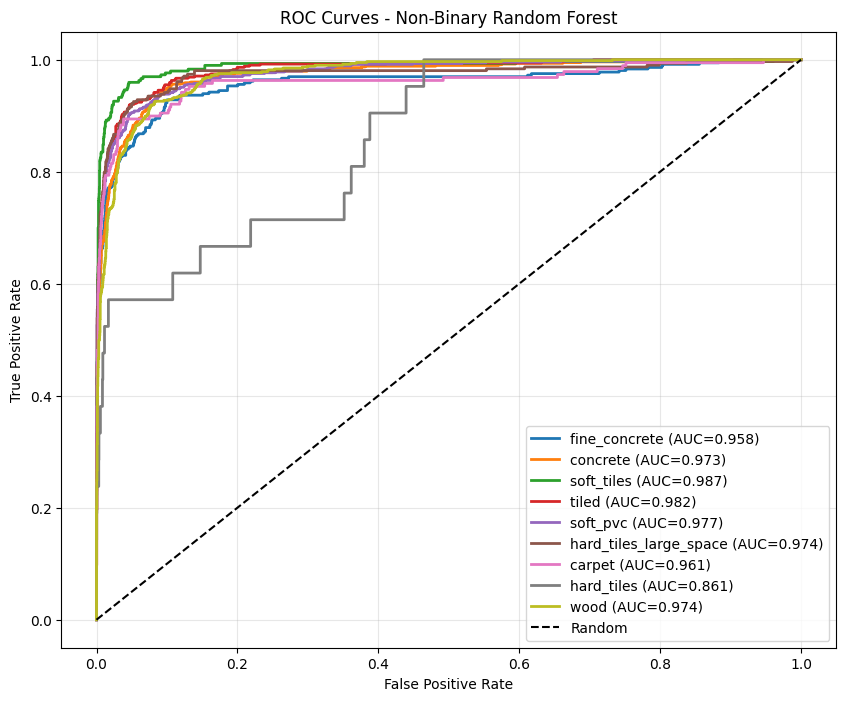

In [ ]:
def plot_roc_curve_manual(model, X, y, num_classes, class_names):
    plt.figure(figsize=(10, 8))
    probs = model.predict_proba(X).numpy()
    y_np = y.numpy()

    actual_num_classes = probs.shape[1]
    print(f"Количество классов в модели: {actual_num_classes}")
    print(f"Ожидалось классов: {num_classes}")

    for c in range(actual_num_classes):
        y_binary = (y_np == c).astype(int)
        scores = probs[:, c]

        indices = np.argsort(scores)[::-1]
        y_sorted = y_binary[indices]

        tpr = [0]
        fpr = [0]
        tp, fp = 0, 0
        n_pos, n_neg = y_binary.sum(), (1 - y_binary).sum()

        if n_pos == 0 or n_neg == 0:
            print(f"Класс {c} не имеет положительных или отрицательных примеров")
            continue

        for label in y_sorted:
            if label == 1:
                tp += 1
            else:
                fp += 1
            tpr.append(tp / n_pos)
            fpr.append(fp / n_neg)

        auc_value = 0
        for i in range(1, len(fpr)):
            auc_value += (fpr[i] - fpr[i-1]) * (tpr[i] + tpr[i-1]) / 2

        label = class_names[c] if c < len(class_names) else f'Class {c}'
        plt.plot(fpr, tpr, label=f'{label} (AUC={auc_value:.3f})', linewidth=2)

    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves - Non-Binary Random Forest')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.show()

unique_classes = torch.unique(rf.predict(X))
actual_num_classes = len(unique_classes)
plot_roc_curve_manual(rf, X, y_enc, actual_num_classes, list(classes[:actual_num_classes]))